In [1]:
!pip install missingno
!pip install xgboost lightgbm scikit-learn

In [2]:
import pandas as pd
import numpy as np
import warnings
import gc
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import (RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor)
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from scipy.cluster import hierarchy
from scipy.spatial.distance import squareform
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")

In [3]:
df = pd.read_csv("/kaggle/input/datasets/duyem54/43-temp/data_43_temp.csv", skiprows=[1,2]) #trước mắt bỏ 2 dòng đầu cho dễ xử lí
# df = pd.read_csv("/kaggle/input/datasets/anhduy54/43-wind/Data_WindSpeed_43.csv")
print(f"temp_dataset: {df.shape}")

temp_dataset: (17526, 44)


---
# **Create Missing Data**

In [4]:
def generate_fixed_length_gaps(df_input, gap_days, num_gaps=10, seed=42, rows_per_day=8):
    """
    Tạo bộ dữ liệu missing với CÙNG MỘT độ dài gap cho tất cả các vị trí được chọn.
    Có tích hợp thuật toán chống đè (anti-overlap) để đảm bảo các gap không dính vào nhau.
    """
    df_temp = df_input.copy(deep=True)
    feature_columns = [col for col in df_temp.columns if col != "TimeVN"]
    
    # Đảm bảo format datetime để tìm đúng 1:00 AM
    ts = pd.to_datetime(df_temp['TimeVN'], format='mixed', dayfirst=True, errors='coerce')
    
    # Lấy ra vị trí (integer index) của các dòng có giờ = 1
    # Dùng np.where để lấy vị trí tuyệt đối, an toàn hơn loc khi thao tác
    daily_start_positions = np.where(ts.dt.hour == 1)[0].tolist()
    
    np.random.seed(seed)
    gap_rows = gap_days * rows_per_day
    
    # Dictionary lưu lại các index bị xóa để sau này tính RMSE, MAE
    missing_ground_truth = {col: [] for col in feature_columns}

    for col in feature_columns:
        col_idx = df_temp.columns.get_loc(col)
        
        # Chỉ giữ lại các vị trí bắt đầu mà khi cộng thêm gap_rows không vượt quá chiều dài data
        valid_starts = [pos for pos in daily_start_positions if pos + gap_rows <= len(df_temp)]
        
        available_starts = valid_starts.copy()
        
        for _ in range(num_gaps):
            if not available_starts:
                print(f"Cảnh báo: Không đủ khoảng trống để tạo đủ {num_gaps} gaps cho cột {col}")
                break
                
            # Chọn ngẫu nhiên 1 vị trí bắt đầu
            start_pos = np.random.choice(available_starts)
            end_pos = start_pos + gap_rows
            
            # Xóa dữ liệu (gán NaN)
            df_temp.iloc[start_pos:end_pos, col_idx] = np.nan
            
            # Lưu lại vị trí đã đục lỗ
            missing_ground_truth[col].extend(list(range(start_pos, end_pos)))
            
            # --- CƠ CHẾ CHỐNG ĐÈ (ANTI-OVERLAP) ---
            # Xóa bỏ các vị trí bắt đầu (start_pos) lân cận ra khỏi danh sách available_starts
            # Khoảng cách tối thiểu giữa 2 điểm bắt đầu phải lớn hơn chiều dài của gap
            available_starts = [pos for pos in available_starts if abs(pos - start_pos) > gap_rows]

    return df_temp, missing_ground_truth

# ================= TẠO 4 BỘ DATASET ĐỘC LẬP =================

# Giả sử 'df' là dataframe gốc của bạn
gap_scenarios = [1, 3, 5, 7]
missing_datasets = {}       # Chứa 4 dataframe đã bị đục lỗ
ground_truth_indices = {}   # Chứa vị trí các lỗ hổng để tính sai số sau này

for days in gap_scenarios:
    print(f"Đang tạo dataset cho kịch bản missing {days} ngày liên tục...")
    
    # Gọi hàm cho từng độ dài
    df_miss, truth_dict = generate_fixed_length_gaps(
        df_input=df, 
        gap_days=days, 
        num_gaps=10,   # Tùy chỉnh số lượng đoạn đứt gãy bạn muốn tạo
        seed=42,       # Giữ nguyên seed để kết quả random có thể tái lập được
        rows_per_day=8
    )
    
    # Lưu vào dictionary
    missing_datasets[f'gap_{days}d'] = df_miss
    ground_truth_indices[f'gap_{days}d'] = truth_dict
    
    total_nan = df_miss.isna().sum().sum()
    print(f"-> Hoàn tất! Tổng số NaN tạo ra: {total_nan}\n")

# Để truy xuất data sử dụng:
df_1_day = missing_datasets['gap_1d']
df_3_days = missing_datasets['gap_3d']
df_5_days = missing_datasets['gap_5d']
df_7_days = missing_datasets['gap_7d']

df_missing = df_7_days

Đang tạo dataset cho kịch bản missing 1 ngày liên tục...
-> Hoàn tất! Tổng số NaN tạo ra: 3440

Đang tạo dataset cho kịch bản missing 3 ngày liên tục...
-> Hoàn tất! Tổng số NaN tạo ra: 10320

Đang tạo dataset cho kịch bản missing 5 ngày liên tục...
-> Hoàn tất! Tổng số NaN tạo ra: 17200

Đang tạo dataset cho kịch bản missing 7 ngày liên tục...
-> Hoàn tất! Tổng số NaN tạo ra: 24080



<Axes: >

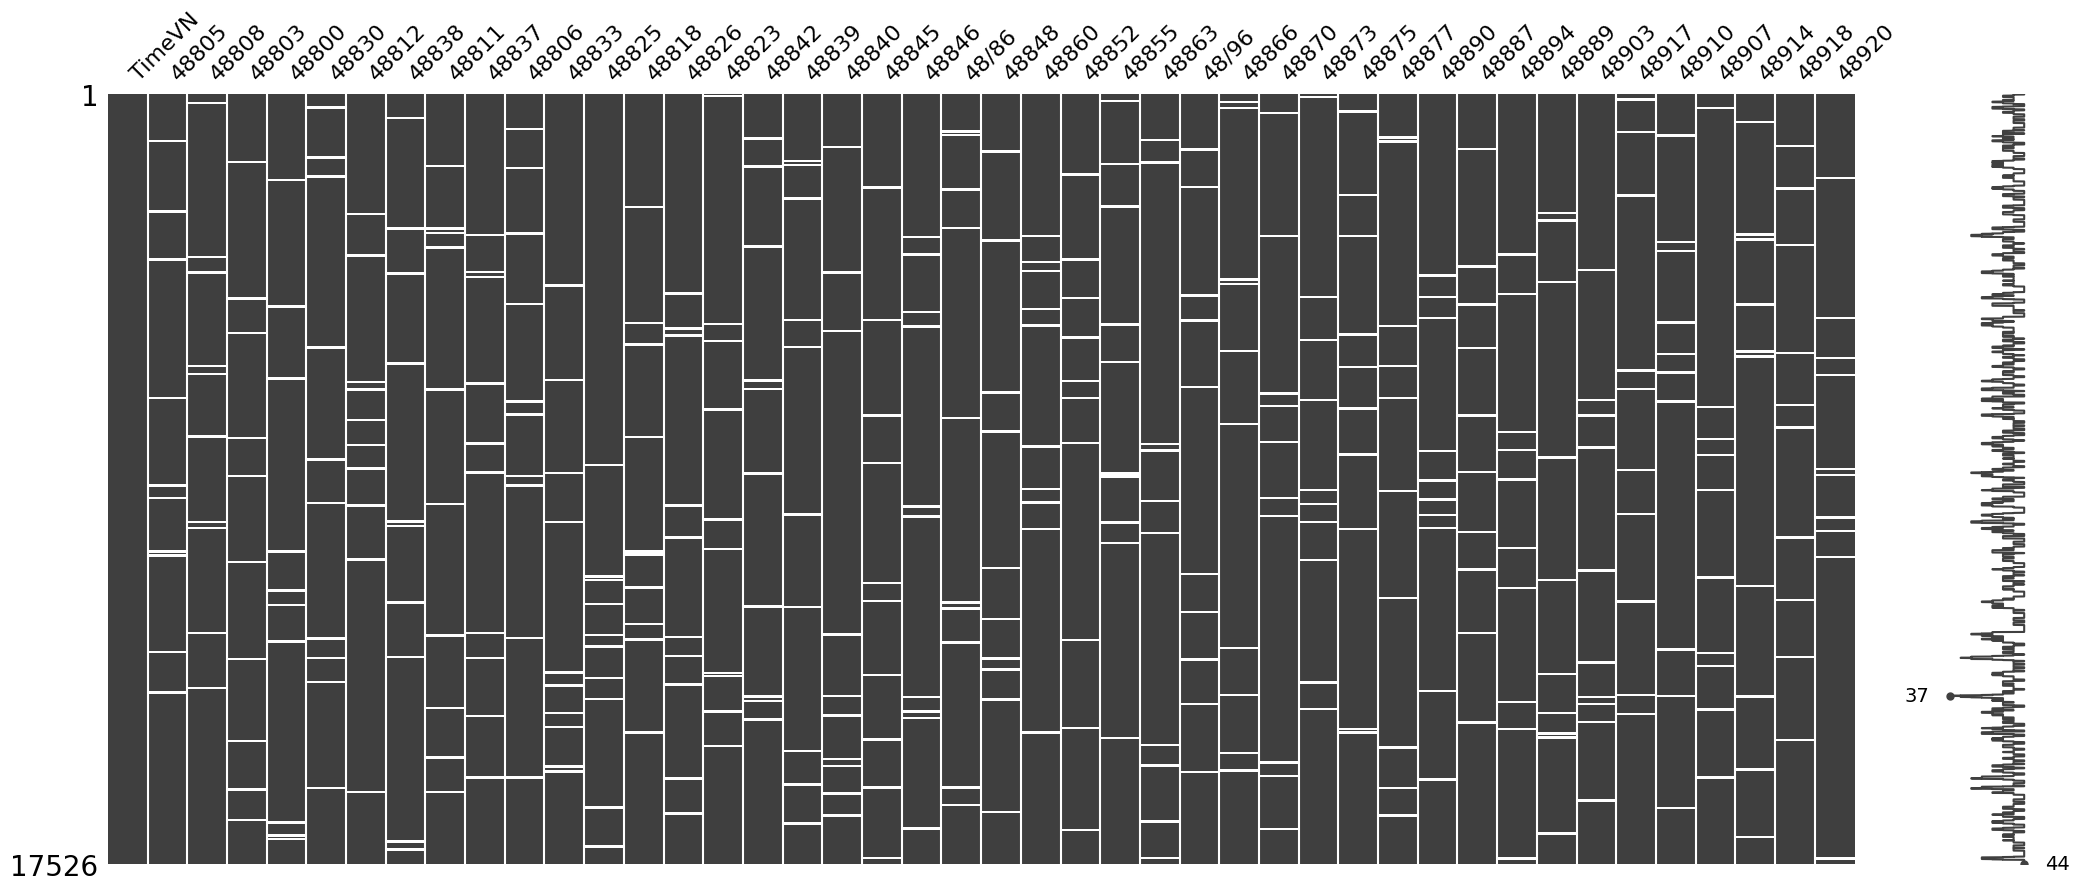

In [5]:
import missingno as msno
msno.matrix(df_missing)

In [6]:
def split_by_hierarchical_correlation(df, low_thresh, high_thresh, time_col='TimeVN'):
    # Tách dữ liệu số để tính toán
    df_numeric = df.select_dtypes(include=[np.number])
    
    # 1. Ensemble Correlation
    corr = (df_numeric.corr(method='pearson').abs() + 
            df_numeric.corr(method='spearman').abs()) / 2
    
    # 2. Distance Matrix & Linkage (Dùng cho Dendrogram)
    dist_matrix = 1 - corr.fillna(0)
    dist_vec = squareform(dist_matrix, checks=False)
    linkage_matrix = hierarchy.ward(dist_vec)
    
    # 3. Tính Degree Centrality (Mức độ quan trọng trung bình của biến trong mạng lưới)
    global_scores = (corr.sum() - 1) / (len(corr) - 1)
    
    # 4. Phân tách theo 3 ngưỡng
    # Low: score < 0.3
    low_cols = global_scores[global_scores < low_thresh].index.tolist()
    # Medium: 0.3 <= score < 0.8
    med_cols = global_scores[(global_scores >= low_thresh) & (global_scores < high_thresh)].index.tolist()
    # High: score >= 0.8
    high_cols = global_scores[global_scores >= high_thresh].index.tolist()
    
    # 5. Trả kết quả (Kèm theo cột thời gian nếu có)
    time_list = [time_col] if time_col in df.columns else []
    
    df_low = df[time_list + low_cols]
    df_med = df[time_list + med_cols]
    df_high = df[time_list + high_cols]
    
    return df_low, df_med, df_high, global_scores, linkage_matrix

# --- Thực thi ---
df_low, df_med, df_high, scores, linkage = split_by_hierarchical_correlation(df_missing, low_thresh=0.6, high_thresh=0.75)

---
# **Models : MLP(spatial) + Embedding(temporal) + LSTM/GRU**

In [7]:
# ==========================================
# 1. TẠO SEED (PRE-IMPUTATION FLEXIBLE)
# ==========================================
def get_seed_data(df_miss, method='linear'):
    """
    Tạo dữ liệu mồi (seed) để các model ML có feature đầu vào.
    Hỗ trợ 3 methods: 'linear', 'spline' (non-linear), 'mean'
    """
    df_num = df_miss.select_dtypes(include=[np.number]).copy().astype('float32')
    
    if method == 'linear':
        df_num = df_num.interpolate(method='linear', limit_direction='both')
    elif method == 'spline':
        # Non-linear interpolation sử dụng spline bậc 3
        df_num = df_num.interpolate(method='spline', order=3, limit_direction='both')
    elif method == 'mean':
        df_num = df_num.fillna(df_num.mean())
    else:
        raise ValueError("Method phải là 'linear', 'spline', hoặc 'mean'")
        
    return df_num.ffill().bfill().fillna(0)

# ==========================================
# 2. MACHINE LEARNING IMPUTATION CORE
# ==========================================
def get_ml_models():
    """Định nghĩa dictionary chứa tất cả các mô hình để dễ dàng gọi và chỉnh sửa tham số"""
    return {
        'LN': LinearRegression(n_jobs=-1),
        'Ridge': Ridge(alpha=1.0),
        'Lasso': Lasso(alpha=0.1),
        'KNN': KNeighborsRegressor(n_neighbors=5, n_jobs=-1),
        'DT': DecisionTreeRegressor(random_state=42),
        'SVR': SVR(kernel='rbf'), 
        'RF': RandomForestRegressor(n_estimators=50, n_jobs=-1, random_state=42),
        'GB': GradientBoostingRegressor(n_estimators=50, random_state=42),
        'Ada': AdaBoostRegressor(n_estimators=50, random_state=42),
        'XGB': XGBRegressor(n_estimators=50, n_jobs=-1, random_state=42, verbosity=0),
        'LGBM': LGBMRegressor(n_estimators=50, n_jobs=-1, random_state=42, verbose=-1)
    }

def run_ml_imputation(df_miss, df_seed, model_name):
    df_num = df_miss.select_dtypes(include=[np.number]).astype('float32')
    target_cols = df_num.columns.tolist()
    working = df_seed[target_cols].copy()
    
    models_dict = get_ml_models() # Lấy danh sách model từ hàm đã định nghĩa ở trên
    if model_name not in models_dict:
        raise ValueError(f"Mô hình {model_name} chưa được định nghĩa!")
        
    model = models_dict[model_name]
    
    # Bổ sung tqdm ở đây: Dùng leave=False để thanh này biến mất khi model chạy xong, nhường chỗ cho model tiếp theo
    pbar_targets = tqdm(target_cols, desc=f"⏳ Đang train {model_name:<5}", leave=False)
    
    for target in pbar_targets:
        m_idx = df_num[target].isna()
        if not m_idx.any(): 
            continue
        
        pred_cols = [c for c in target_cols if c != target]
        
        X_train = working.loc[~m_idx, pred_cols].values
        y_train = working.loc[~m_idx, target].values
        X_test = working.loc[m_idx, pred_cols].values
        
        # Fit & Predict
        model.fit(X_train, y_train)
        working.loc[m_idx, target] = model.predict(X_test)
        
    return working

# ==========================================
# 3. FULL METRICS EVALUATION
# ==========================================
def get_final_metrics(df_orig, df_imp, df_miss):
    stats = []
    common_cols = [c for c in df_miss.columns if c in df_orig.columns and c in df_imp.columns and c not in ['TimeVN', 'Time', 'Date']]
    
    for col in common_cols:
        mask = pd.isna(df_miss[col].values) & ~pd.isna(df_orig[col].values)
        yt, yp = df_orig[col].values[mask], df_imp[col].values[mask]
        valid = ~np.isnan(yp); yt, yp = yt[valid], yp[valid]
        if len(yt) < 2: continue
            
        T = len(yt)
        v_min, v_max = np.nanmin(df_orig[col].values), np.nanmax(df_orig[col].values)
        rng = v_max - v_min if v_max > v_min else 1.0
        
        rmse = np.sqrt(np.mean((yt - yp)**2))
        mae = np.mean(np.abs(yp - yt))
        sim = (1/T) * np.sum(1 / (1 + (np.abs(yp - yt) / rng)))
        nmae = mae / rng
        fb = 2 * np.mean(yp - yt) / (np.mean(yp) + np.mean(yt) + 1e-9)
        
        nse = 1 - (np.sum((yt - yp)**2) / (np.sum((yt - np.mean(yt))**2) + 1e-9))
        r2 = r2_score(yt, yp)
        
        stats.append({
            "Station": col, "NSE": nse, "R2": r2, "Sim": sim,
            "RMSE": rmse, "MAE": mae, "NMAE": nmae, "FB": fb
        })
    return pd.DataFrame(stats)

# ==========================================
# 4. EXECUTION PIPELINE (ALL SEED METHODS)
# ==========================================

# Danh sách các phương pháp tạo Seed và các Mô hình muốn test
seed_methods_to_test = ['mean', 'linear', 'spline']
models_to_test = ['LN', 'Ridge', 'Lasso', 'KNN', 'DT', 'RF', 'GB', 'Ada', 'XGB', 'LGBM', 'SVR']

comparison_data = []

print("🚀 Đang khởi động chiến dịch Test toàn diện...\n")

# Vòng lặp 1: Chạy qua từng phương pháp Pre-imputation
pbar_seeds = tqdm(seed_methods_to_test, desc="🌟 TỔNG TIẾN TRÌNH SEED", colour='blue', position=0)

for SEED_METHOD in pbar_seeds:
    # Lấy dữ liệu mồi tương ứng với phương pháp hiện tại
    df_seed = get_seed_data(df_missing, method=SEED_METHOD)
    
    # Vòng lặp 2: Chạy qua các mô hình (leave=False để chạy xong nhóm này nó nhường chỗ cho nhóm sau)
    pbar_models = tqdm(models_to_test, desc=f"🏆 Đang chạy ({SEED_METHOD})", colour='green', position=1, leave=False)
    
    for model_name in pbar_models:
        # 1. Chạy Imputation (Hàm run_ml_imputation đã có sẵn thanh tqdm thứ 3 bên trong)
        df_imp = run_ml_imputation(df_missing, df_seed, model_name=model_name)
        
        # 2. Đánh giá sai số
        metrics_df = get_final_metrics(df, df_imp, df_missing)
        if not metrics_df.empty:
            s = metrics_df.mean(numeric_only=True)
            comparison_data.append({
                'Seed_Method': SEED_METHOD.upper(),
                'Model': model_name,
                'NSE (↑)': s['NSE'], 'R2 (↑)': s['R2'], 'Sim (↑)': s['Sim'],
                'RMSE (↓)': s['RMSE'], 'MAE (↓)': s['MAE'], 'NMAE (↓)': s['NMAE']
            })
            
        # Xóa rác bộ nhớ để tránh tràn RAM khi chạy vòng lặp lớn
        del df_imp
        gc.collect()

# ==========================================
# 5. HIỂN THỊ KẾT QUẢ TỔNG HỢP
# ==========================================
# Tạo DataFrame và thiết lập Multi-Index để bảng trông chuyên nghiệp, dễ so sánh
final_df = pd.DataFrame(comparison_data)

# Sắp xếp lại thứ tự cho đẹp mắt (Nhóm theo Seed, rồi sắp xếp Model theo Alphabet)
final_df = final_df.sort_values(by=['Seed_Method', 'Model']).set_index(['Seed_Method', 'Model'])

print("\n" + "="*85)
print("BẢNG TỔNG HỢP ĐÁNH GIÁ ĐA PHƯƠNG PHÁP PRE-IMPUTATION VÀ MACHINE LEARNING")
print("="*85)

# Đổ màu cho bảng (xanh lá = tốt, đỏ = kém)
display(final_df.style.format(precision=4)\
    .background_gradient(cmap='RdYlGn', subset=['NSE (↑)', 'R2 (↑)', 'Sim (↑)'])\
    .background_gradient(cmap='RdYlGn_r', subset=['RMSE (↓)', 'MAE (↓)']))

🚀 Đang khởi động chiến dịch Test toàn diện...



🌟 TỔNG TIẾN TRÌNH SEED:   0%|          | 0/3 [00:00<?, ?it/s]

🏆 Đang chạy (mean):   0%|          | 0/11 [00:00<?, ?it/s]

⏳ Đang train LN   :   0%|          | 0/43 [00:00<?, ?it/s]

⏳ Đang train Ridge:   0%|          | 0/43 [00:00<?, ?it/s]

...

⏳ Đang train Ada  :   0%|          | 0/43 [00:00<?, ?it/s]

⏳ Đang train XGB  :   0%|          | 0/43 [00:00<?, ?it/s]

⏳ Đang train LGBM :   0%|          | 0/43 [00:00<?, ?it/s]

⏳ Đang train SVR  :   0%|          | 0/43 [00:00<?, ?it/s]


BẢNG TỔNG HỢP ĐÁNH GIÁ ĐA PHƯƠNG PHÁP PRE-IMPUTATION VÀ MACHINE LEARNING
